# Week 3 Draft: Qualitative Analysis and Insights

This notebook draft focuses on the qualitative interpretation of the IDX next-day stock direction prediction project. It complements the quantitative metric explanation by discussing what the model behavior means from a trading, sector, and Indonesia macro-market perspective.


## 1. Positioning of the Model

The final model should be interpreted as a predictive screening model, not as a complete trading strategy. The notebook builds a reasonable machine-learning pipeline for next-day direction classification using Energy and Technology stocks, lagged/rolling technical features, a temporal train-validation-test split, and a Random Forest final model. However, the output is still a probability or direction signal, not an investable strategy.

A trading strategy would require additional components that are not included here: entry and exit rules, portfolio construction, position sizing, turnover control, transaction costs, bid-ask spread and slippage assumptions, liquidity filters, benchmark comparison, and risk metrics such as drawdown or Sharpe ratio. Because these elements are absent, the model is best described as a research signal that could help prioritize stocks for further analysis.


## 2. Summary of Predictive Behavior

The Random Forest model shows weak-to-modest predictive signal. The test set contains 7,301 observations, with only around 35.6% of observations labeled as Up. This means Down/Flat days dominate the data, so ordinary accuracy is not the most useful metric. A naive classifier that always predicts Down/Flat would reach about 64.4% accuracy, but it would completely fail to identify Up opportunities.

The final model has a ROC-AUC of about 0.586, PR-AUC of about 0.425, balanced accuracy of about 0.543, and MCC of about 0.121. These values suggest that the model is not random, but the signal is limited. The model also predicts Up for around 86.4% of test observations. This produces high recall for Up movements, around 91.9%, but low precision, around 37.9%. In practical terms, the model is good at catching many Up cases, but it also produces many false positives.

This behavior matters because a model that buys too many stocks may perform poorly after trading costs. The precision lift is only about 2.3 percentage points above the Up base rate, from 35.6% to 37.9%. A high-recall signal can look acceptable in classification metrics while still being economically weak if the positive predictions are not selective enough.


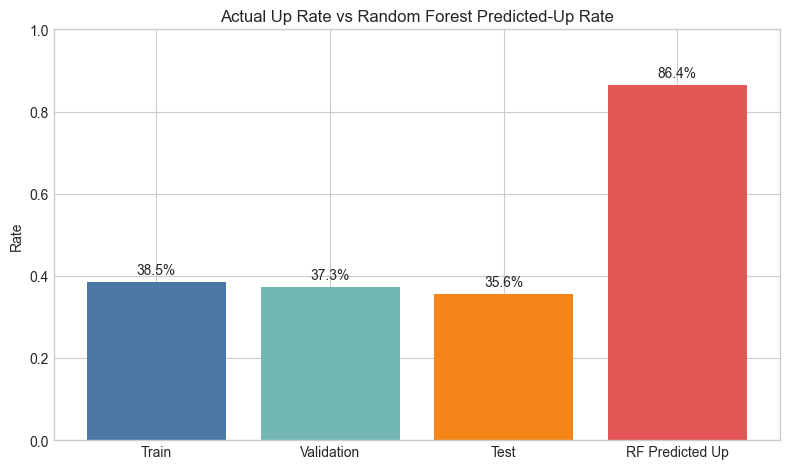

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

class_balance = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test', 'RF Predicted Up'],
    'Up Rate': [0.385, 0.373, 0.356, 0.864],
})

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(class_balance['Split'], class_balance['Up Rate'], color=['#4C78A8', '#72B7B2', '#F58518', '#E45756'])
ax.set_title('Actual Up Rate vs Random Forest Predicted-Up Rate')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
for bar in bars:
    value = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.1%}', ha='center')
plt.tight_layout()
plt.show()

**Evidence note:** it shows why accuracy alone is misleading. The actual Up rate in the test period is only 35.6%, but the Random Forest predicts Up for 86.4% of rows. This supports the claim that the model has high recall but weak selectivity.


## 3. Sector Interpretation

The two selected sectors have different market characteristics. Energy stocks are more exposed to commodity cycles, export policy, global demand, and exchange-rate conditions. Technology stocks are more exposed to growth expectations, liquidity, investor sentiment, interest rates, and profitability narratives.

In the test period, Energy has a higher Up base rate than Technology. Energy's Up rate is around 38.7% across 4,315 test observations, while Technology's Up rate is around 31.1% across 2,986 test observations. This partly explains why the model's F1 score for Up is stronger in Energy than in Technology. Technology has fewer Up observations, making positive-direction prediction more difficult.

The Random Forest ROC-AUC is slightly higher for Technology, about 0.587, compared with about 0.573 for Energy. However, the F1 score for Up is higher in Energy, about 0.565, compared with about 0.491 for Technology. Precision also differs: about 40.7% in Energy versus 33.6% in Technology. This suggests that the model may rank Technology outcomes slightly better, but it has a harder time converting that ranking into accurate Up predictions because Technology Up movements are less frequent in the test period.


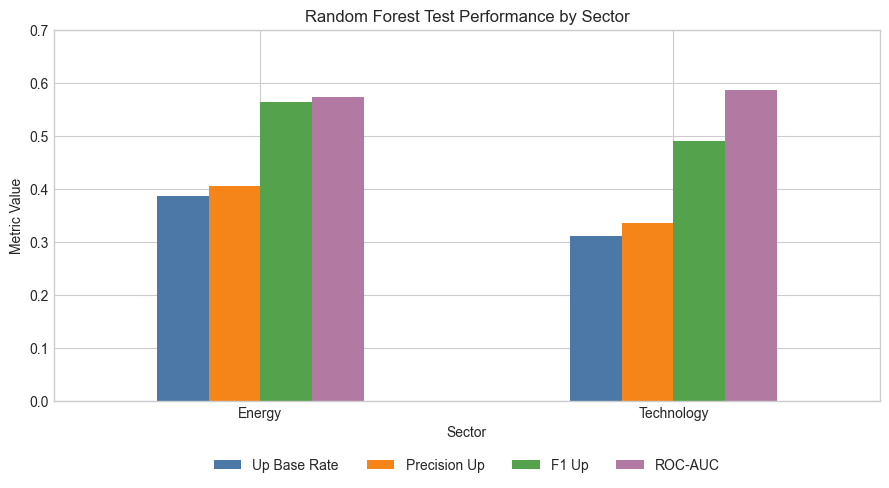

In [2]:
sector_metrics = pd.DataFrame({
    'Sector': ['Energy', 'Technology'],
    'Up Base Rate': [0.3866, 0.3111],
    'Precision Up': [0.4065, 0.3364],
    'F1 Up': [0.5652, 0.4907],
    'ROC-AUC': [0.5733, 0.5873],
})

fig, ax = plt.subplots(figsize=(9, 5))
sector_metrics.set_index('Sector').plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518', '#54A24B', '#B279A2'])
ax.set_title('Random Forest Test Performance by Sector')
ax.set_ylabel('Metric Value')
ax.set_ylim(0, 0.7)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Evidence note:** Energy has a higher Up base rate and stronger F1 Up, while Technology has slightly higher ROC-AUC. This supports the sector interpretation that Technology outcomes may be rankable but harder to convert into accurate Up predictions because Up days are less frequent.


## 4. Feature-Based Interpretation

The most important Random Forest features are mainly technical and liquidity-related signals, including high-low spread, price position, price relative to moving averages, volume ratios, log volume, short-term volatility, daily return, and momentum. The top features include `high_low_spread` with importance around 0.040, `price_vs_ma5` around 0.038, `price_position` around 0.035, `price_vs_ma10` around 0.034, `volume_ratio_50d` around 0.033, `log_volume` around 0.031, and `volatility_5d` around 0.029.

Qualitatively, this means the model relies on short-term market behavior rather than fundamental company information. This claim is supported by the fact that the highest-ranked features are all technical OHLCV-derived variables rather than accounting, earnings, valuation, or macro variables. Price relative to moving averages can capture trend or mean-reversion behavior. High-low spread and volatility can reflect uncertainty or intraday pressure. Volume features can capture trading attention, liquidity shocks, or institutional and retail flow. Momentum features can capture continuation after recent price moves.

These features are intuitive for short-horizon prediction, but they should not be interpreted as causal drivers. For example, high volume may appear predictive because it reflects news, market stress, or investor repositioning, not because volume itself causes next-day returns.


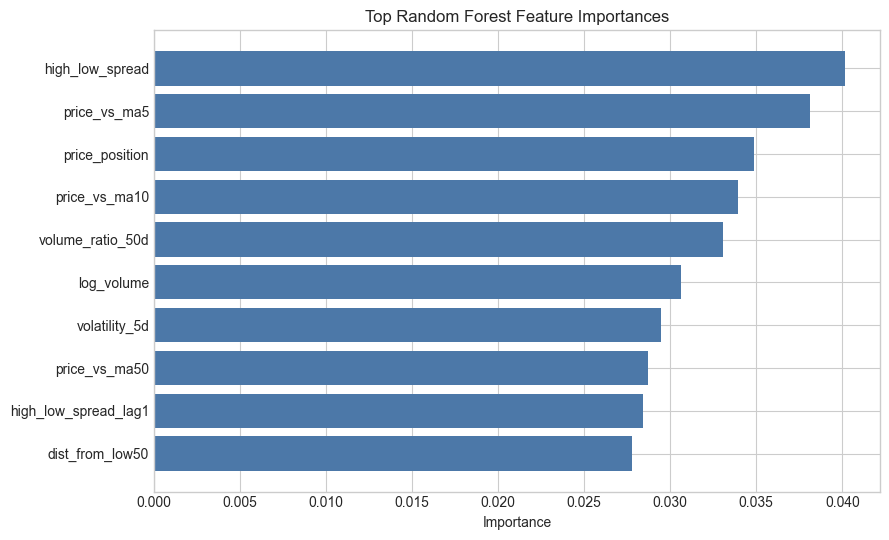

In [3]:
feature_importance = pd.DataFrame({
    'Feature': [
        'high_low_spread', 'price_vs_ma5', 'price_position', 'price_vs_ma10',
        'volume_ratio_50d', 'log_volume', 'volatility_5d', 'price_vs_ma50',
        'high_low_spread_lag1', 'dist_from_low50'
    ],
    'Importance': [0.040184, 0.038150, 0.034861, 0.033939, 0.033081,
                   0.030614, 0.029487, 0.028709, 0.028422, 0.027793],
})

fig, ax = plt.subplots(figsize=(9, 5.5))
ordered = feature_importance.sort_values('Importance')
ax.barh(ordered['Feature'], ordered['Importance'], color='#4C78A8')
ax.set_title('Top Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Evidence note:** the highest-ranked features are technical OHLCV features, especially spread, price position, moving-average distance, volume, and volatility. This supports the interpretation that the model learns short-term trading pressure rather than company fundamentals.


## 5. Time-Slice Interpretation

The model's test-period behavior is fairly stable across early 2024. In 2024Q1, the Random Forest has ROC-AUC around 0.582 and F1 Up around 0.536 across 4,999 observations. In 2024Q2, ROC-AUC improves slightly to around 0.594, while F1 Up remains almost unchanged at around 0.537 across 2,302 observations.

This supports the claim that the model has a consistent but modest short-term signal. The signal does not disappear between Q1 and Q2, but it also does not become strong enough to support confident trading decisions. The Up base rate is also similar across the two periods, around 35.4% in 2024Q1 and 35.9% in 2024Q2, so the model is being tested under a relatively similar class-balance environment during early 2024.


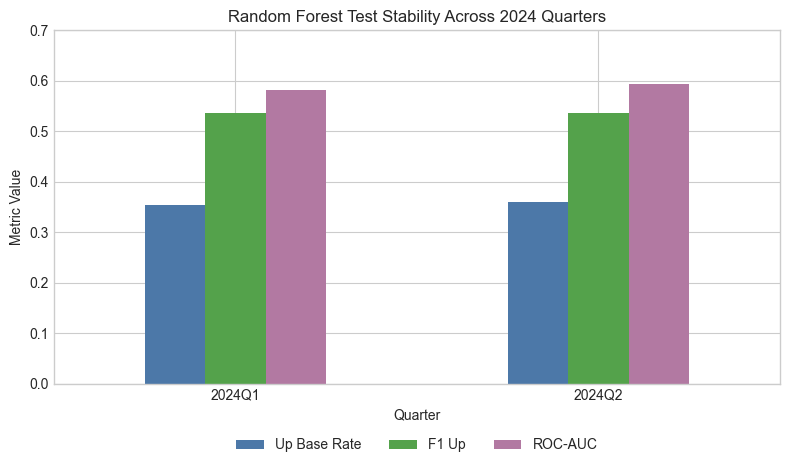

In [4]:
quarter_metrics = pd.DataFrame({
    'Quarter': ['2024Q1', '2024Q2'],
    'Up Base Rate': [0.3541, 0.3593],
    'F1 Up': [0.5362, 0.5369],
    'ROC-AUC': [0.5824, 0.5944],
})

fig, ax = plt.subplots(figsize=(8, 4.8))
quarter_metrics.set_index('Quarter').plot(kind='bar', ax=ax, color=['#4C78A8', '#54A24B', '#B279A2'])
ax.set_title('Random Forest Test Stability Across 2024 Quarters')
ax.set_ylabel('Metric Value')
ax.set_ylim(0, 0.7)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Evidence note:** Q1 and Q2 have similar F1 Up and similar Up base rates. ROC-AUC improves slightly in Q2, but both quarters remain below 0.60, supporting the claim that the signal is stable but modest.


## 6. Indonesia Macro and Market Context, 2020-2024

The 2020-2024 period contains several different regimes, which helps explain why next-day prediction is difficult. The model is trained over a period that includes pandemic disruption, recovery, commodity shocks, interest-rate tightening, and post-boom normalization.

In 2020, the COVID-19 pandemic caused major uncertainty and market dislocation. Volatility, spreads, and price-position features likely captured stress and recovery dynamics during this period. Energy stocks faced demand uncertainty, while Technology stocks benefited from digital adoption narratives but were also sensitive to speculative liquidity.

In 2021, Indonesia's recovery strengthened and Technology became a major market theme. Digital-economy enthusiasm and large technology listings contributed to strong investor attention. In this environment, momentum and volume features may have been informative because prices were being repriced around growth expectations and retail participation.

In 2022, the regime changed. Global commodity prices increased after Russia's invasion of Ukraine, supporting coal and energy-linked equities. Indonesia also experienced policy events around coal exports and domestic energy obligations. At the same time, inflation pressure increased, fuel prices were raised in September 2022, and Bank Indonesia began raising policy rates. This combination favored Energy earnings expectations but pressured high-growth Technology valuations.

In 2023, the market entered a more stable but tighter financial environment. Higher interest rates and rupiah-stability concerns reduced the easy-liquidity backdrop that had supported growth stocks. Energy stocks also faced normalization after the 2022 commodity windfall. In this regime, price-position and momentum features could still capture short-term continuation or reversal, but macro regime shifts likely weakened model stability.

In 2024, Indonesia's economy remained resilient, but the equity market became more selective. Energy was influenced by commodity normalization, policy risk, and global demand expectations. Technology was judged more by profitability, funding conditions, valuation discipline, and business execution. This explains why technical features can provide some signal, but not enough to create a strong standalone prediction model. The 2024 test metrics support this: ROC-AUC remains below 0.60 in both Q1 and Q2, showing that the model ranks outcomes better than random but still only weakly.


## 7. Key Insights

First, the model captures some weak but non-random short-term structure in IDX Energy and Technology stocks. The signal is visible in ranking metrics such as ROC-AUC, with the final Random Forest reaching about 0.586 on the test set, but it is not strong enough to justify standalone trading.

Second, the model's important features align with market intuition. Short-term price position, volatility, spread, volume, and momentum are reasonable predictors for next-day direction because they summarize recent trading pressure and market attention. This is supported by the top feature importances: `high_low_spread` around 0.040, `price_vs_ma5` around 0.038, `price_position` around 0.035, and `volume_ratio_50d` around 0.033.

Third, sector context matters. Energy stocks are more connected to commodity and policy cycles, while Technology stocks are more connected to liquidity, growth expectations, and valuation sentiment. The same technical features can therefore have different meanings across sectors. This is visible in the test set: Energy has a higher Up rate, around 38.7%, and higher F1 Up, around 0.565, while Technology has a lower Up rate, around 31.1%, and lower F1 Up, around 0.491.

Fourth, the 2020-2024 sample combines several macro regimes. Pandemic shock, recovery, technology enthusiasm, commodity boom, inflation, interest-rate tightening, and 2024 selectivity all appear in the same training window. This makes stable next-day prediction difficult and helps explain why the final model performance is modest, with balanced accuracy only around 0.543 and MCC around 0.121.

Finally, the model should be presented as a decision-support tool. It may help investors identify stocks that deserve further review, but it should be combined with macro context, sector fundamentals, liquidity checks, and risk controls before being used in an investment process.


## 8. Limitations and Future Work

The current project focuses on classification performance, not trading profitability. Future work should add a walk-forward backtest, transaction costs, liquidity filters, turnover limits, position sizing, and benchmark comparison. The model should also be tested using expected return or risk-adjusted return objectives, not only Up/Down classification.

Future versions could also include macro and market-wide variables, such as JCI index returns, sector index returns, exchange rates, interest rates, commodity prices, and global risk indicators. These features may help the model distinguish between technical noise and broader regime changes.

Finally, the project should consider corporate actions and survivorship effects more carefully. Using current stock lists and full-sample ticker availability is acceptable for a course screening model, but a stricter historical trading simulation would need point-in-time universe construction and tradable execution assumptions.


## 9. Presentation-Ready Version

- The model is a screening model, not a complete trading strategy.
- The Random Forest finds weak but non-random next-day direction signal.
- Important features are mostly technical: spread, price position, moving-average distance, volume, volatility, and momentum.
- Energy behavior is linked to commodity cycles and policy events.
- Technology behavior is linked to liquidity, valuation sentiment, IPO/growth narratives, and interest-rate conditions.
- The 2020-2024 period contains multiple regimes, making stable prediction difficult.
- The model should be combined with macro context, sector analysis, liquidity filters, and risk controls before investment use.
- Future work should add a real backtest with transaction costs, slippage, turnover, position sizing, and benchmark comparison.
